# Notebook 5: Explainable AI (XAI) via LIME
## Project: Multi-Paradigm AI vs. Human Text Detection

### Objective
To open the "Black Box" of our models and inspect. High accuracy is insufficient for production systems. We must understand *why* a model makes a prediction to ensure it isn't relying on spurious correlations.

### Methodology: LIME (Local Interpretable Model-Agnostic Explanations)
LIME works by taking a single text, creating hundreds of slightly perturbed variations (dropping or swapping words), and observing how the model's predictions change. This allows us to map exact feature importances back to individual words.

In [149]:
# Importing libraries
import joblib
import pandas as pd
import numpy as np
import torch
import re
from lime.lime_text import LimeTextExplainer
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from transformers import BertTokenizer,BertForSequenceClassification
import torch.nn.functional as F
import gc
import torch
gc.collect()
torch.cuda.empty_cache()

In [150]:
# Loading dataset and sampling a text
df=pd.read_csv("/kaggle/input/datasets/matejkore/ai-detector-dataset/ai_detector_dataset.csv")
random_row=df.sample(1)
sample_text=random_row['text'].iloc[0]
sample_label=random_row['label'].iloc[0]
print(f"Target Label: {sample_label}")
print(f"Target Text: {sample_text}")

Target Label: AI
Target Text: Came for brunch, looked empty on the outside but was surprised to find that the place was full of people upon entering! I came on a Saturday about noon, I saw some regulars sitting at tables and most were not wearing masks. We ordered pastries from their mini bakery in the corner then we walked down the street to the beach area where there is also another caferestaurant called The Mermaids Cafe Art Gallery (tbh it's quite far away from the main strip so might want to check if they have outdoor seating!). We had our usual coffee then went back up to the building across from Mermaid Cafe Art Gallery towards the pool bar (this time with mask) before heading home via Ferry Terminal.


In [151]:
# Loading Logistic Regression model
lr_model=joblib.load("/kaggle/input/datasets/antareepghosh18/ai-detector-dataset/logistic_regression_model.joblib")
tfidf=joblib.load("/kaggle/input/datasets/antareepghosh18/ai-detector-dataset/tfidf_vectorizer.joblib")

In [152]:
# Defining the prediction pipeline for LIME using Logisitc Regression
def lr_predict_pipeline(texts):
    cleaned=[text.lower().replace('\n',' ') for text in texts]
    features=tfidf.transform(cleaned)
    return lr_model.predict_proba(features)
explainer=LimeTextExplainer(class_names=['Human','AI'])

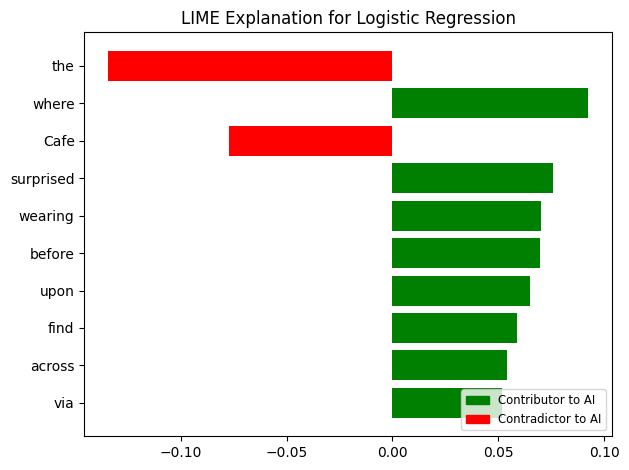

In [153]:
# Testing explainability for a sample using Logistic Regression
exp=explainer.explain_instance(sample_text, 
                               lr_predict_pipeline,
                               labels=(1,),
                               num_features=10)
exp.save_to_file('lime_explanation_lr.html')
fig=exp.as_pyplot_figure(label=1)
green_patch=mpatches.Patch(color='green',label='Contributor to AI')
red_patch=mpatches.Patch(color='red',label='Contradictor to AI')
plt.title("LIME Explanation for Logistic Regression")
plt.legend(handles=[green_patch,red_patch],loc='lower right',fontsize='small')
plt.tight_layout()
plt.show()

In [154]:
# Loading BERT model
bert_path="/kaggle/input/datasets/antareepghosh18/ai-detector-dataset" 
tokenizer=BertTokenizer.from_pretrained(bert_path)
model=BertForSequenceClassification.from_pretrained(bert_path)
model.to('cuda') 
model.eval()
print("BERT Model Loaded Successfully!")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BERT Model Loaded Successfully!


In [155]:
# Defining the prediction pipeline for LIME using Logisitc Regression
def bert_predict_pipeline(texts):
    inputs=tokenizer(texts,padding=True,truncation=True,max_length=350,return_tensors="pt").to('cuda')
    with torch.no_grad():
        outputs=model(**inputs)
        probs=F.softmax(outputs.logits,dim=1)
    return probs.detach().cpu().numpy()

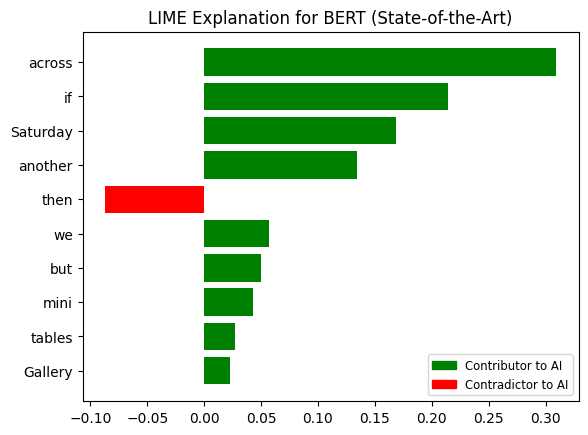

In [156]:
# Testing explainability for a sample using BERT
exp_bert=explainer.explain_instance(sample_text, 
                                    bert_predict_pipeline, 
                                    labels=(1,), 
                                    num_features=10,
                                    num_samples=100)
exp_bert.save_to_file('lime_explanation_bert.html')
fig=exp_bert.as_pyplot_figure(label=1)
plt.title("LIME Explanation for BERT (State-of-the-Art)")
plt.legend(handles=[green_patch,red_patch],loc='lower right',fontsize='small')
plt.show()